# MNIST Classification Analysis

In this notebook, I explore classification tasks using the MNIST dataset, a classic benchmark for handwritten digit recognition. The main idea is to better understand how classification models behave when working with image data represented as pixels.

The analysis starts with a binary classification task and then extends to multiclass classification, allowing a broader view of how different approaches perform. Along the way, this notebook also focuses on model evaluation, performance comparison, and basic error analysis.

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9. Each image has a size of 28 × 28 pixels, meaning that every instance is represented by 784 input features.

In [23]:
# Numpy
import numpy as np

# Matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt

#Pandas


# Scikit-learn
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.base import BaseEstimator
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [24]:
# Load the dataset found in scikit - learn and see its structure with keys.()
mnist = fetch_openml('mnist_784', version = 1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [25]:
X, y = mnist['data'], mnist['target']
X.shape


(70000, 784)

In [26]:
y.shape

(70000,)

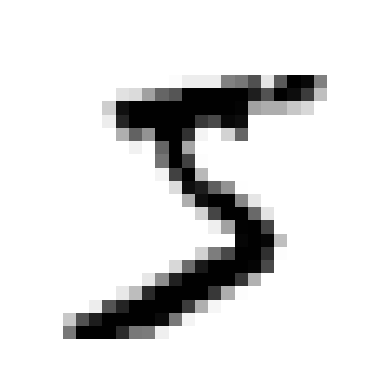

In [27]:
some_digit_image_show = X.iloc[0].to_numpy()
some_digit_image = some_digit_image_show.reshape(28,28)

plt.imshow(some_digit_image, cmap = mpl.cm.binary, interpolation = "nearest")
plt.axis("off")
plt.show()

In [28]:
y[0]


'5'

In [29]:
y = y.astype(np.uint8)

## Splitting the dataset into train and test

The MNIST dataset is actually already split into a training set (the first 60.000 images) and a test set (the last 10.000)

In [30]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Binary Classifier to start

First, let's simplify the classification task of all digits to only if is 5 or not. Let's build a "5-detector".

In [21]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

## SGD classifier 

Using a SGD classifier as a model to classify between 5 and not 5. We are using it just because its good dealing with very large datasets, in part because it trains every instance independly, one at a time. 

In [22]:
sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train, y_train_5)

KeyboardInterrupt: 

In [ ]:
some_digit = X.iloc[[0]]
sgd_clf.predict(some_digit)

array([ True])

## Performance Measures

In [ ]:
# Implementing Cross Validation

skfolds = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))



0.9042
0.9477
0.96785


### Dumb Classifier and Problem with Accuracy in Classification

In [ ]:
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

Great accuracy results, but with an unbalanced dataset this metric is misleading. If 90% of the data are ‘not-5s’ and you always predict ‘not-5’, you will be right 90% of the time — even with a terrible model.

## Confusion Matrix

In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3)

In [ ]:
confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

Each row in the confusion matrix represents an actual class, while each column represents a predicted class.
53892 true negatives(TN) and 3530 true positives(TP) (main diagonal). 1891 false negatives (FN) and 687 false positives(FN).

## Precision
Using a more concise metric to analise the classifier (precision is also called the accuracy of the positive predictions).



$$Precision = \frac{TP}{TP + FP}$$

## Recall (also called sensitivity or true positive rate, TPR)
Is the ratio of positive instances that are correctly detected by the classifier. 


$$Recall = \frac{TP}{TP + FN}$$

In [ ]:
precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [ ]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

## F-1 Score

It's a convinient way of combining precision and recall in one metric, as the f-1 score is the harmonic mean of the two. Moreover, it's a simple way of comparing two classifiers.

$$F1 = \frac{2}{\frac{1}{precision} + \frac{1}{recall}}$$

In [ ]:
f1_score(y_train_5, y_train_pred)

0.7325171197343847

## Decision Threshold for classifiers
Using the decision_function to return the score calculate by the model for the instance [0] (the one we defined some_digit thas in reality was a 5).
We can try different thresholds and compare to the score calculated by the model for this digit.

In [ ]:
y_scores = sgd_clf.decision_function(some_digit)
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[2164.22030239]
[ True]


### Decision Threshold for each instance
What can be really interesting it would be to get the score the model calculated to each instance we have, no only 'some_digit' and use the precision_recall_curve function to analyse different thresholds and how this impact on the metrics.

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 5, method = 'decision_function')

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

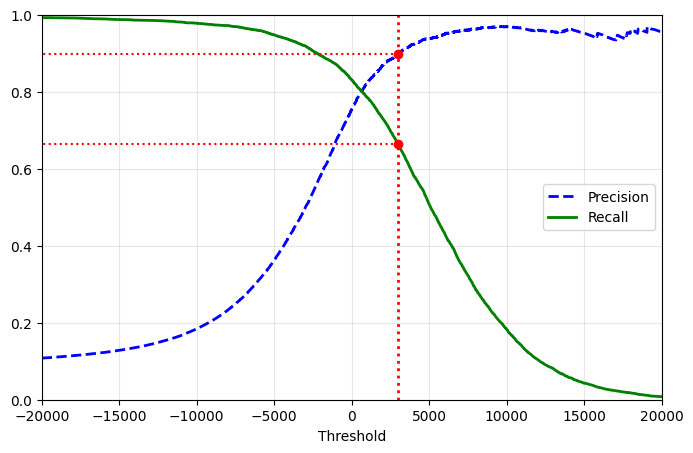

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds, chosen_threshold=3000):
    plt.figure(figsize=(8, 5))

    p = precisions[:-1]
    r = recalls[:-1]

    plt.plot(thresholds, p, "b--", linewidth=2, label="Precision")
    plt.plot(thresholds, r, "g-", linewidth=2, label="Recall")
    plt.axvline(chosen_threshold, color="red", linestyle=":", linewidth=2)
    plt.xlim(-20000, 20000)


    idx = (thresholds >= chosen_threshold).argmax()
    plt.plot(chosen_threshold, p[idx], "ro")
    plt.plot(chosen_threshold, r[idx], "ro")
    plt.hlines(p[idx], xmin=thresholds[0], xmax=chosen_threshold, colors="red", linestyles=":")
    plt.hlines(r[idx], xmin=thresholds[0], xmax=chosen_threshold, colors="red", linestyles=":")

    plt.xlabel("Threshold")
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3)
    plt.legend(loc="center right")
    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds, chosen_threshold = 3000)


With this plot we can see clearly the precision-recall trade-off and even choose a value of precision or recall based on our project.

Consider that we want 90% precision, we can use the np.argmax() function to return to us the lowest threshold to achieve 90% precision. 
We want the lowest one because knowing the trade-off, we know that increasing precision will decrease recall.

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
threshold_90_precision

np.float64(3045.9258227055584)

To make predictions (on the training set for now), instead of calling the classifier’s predict() method, you can just run this code:

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision)
print(y_train_pred_90)

[ True False False ...  True False False]


In [ ]:
precision_score(y_train_5, y_train_pred_90)

0.9002016129032258

In [ ]:
recall_score(y_train_5, y_train_pred_90)

0.6589190186312488

## The ROC Curve

The receiver operating characteristic (ROC) plots the true positive rate (TPR - Recall) against the false positive rate (FPR).

- FPR = 1 - TNR
- TNR = Specificity
- TPR = Sensitivity (Recall)

The ROC curve plots Sensitivity against (1 - Specificity)

In [ ]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

Outputs as fpr and tpr because these are the values we use to plot a ROC curve and thresholds because we want to analyse in different threholds scenarios.
We feed the function with y_train_5 because we need the raw data to compare the predictions and y_scores because we want to analyse all instances's scores variying the threshold.

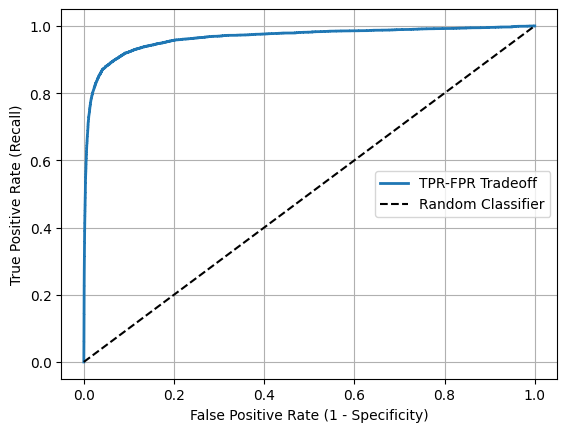

In [ ]:
def plot_roc_curve(fpr, tpr, label = None):
    plt.plot(fpr, tpr, linewidth = 2, label = 'TPR-FPR Tradeoff')
    plt.plot([0,1], [0,1], 'k--', label = 'Random Classifier')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Recall)')
    plt.grid()
    plt.legend(loc = 'center right')
plot_roc_curve(fpr, tpr)
plt.show()    

## ROC AUC — Area Under the ROC Curve

We can compare classifiers by measuring the area under their ROC curve (ROC-AUC), or alternatively the area under the Precision-Recall curve (PR-AUC). A higher AUC means the model is better at consistently ranking real 5s above non-5s, regardless of the internal math each model uses to generate scores. For example, if a Random Forest has a higher ROC-AUC than an SGD Classifier, its scores do a better job of separating the two classes across all possible thresholds.

That said, AUC alone does not directly tell you the probability that a specific new image is a 5. It is a general quality certificate for the model. Only once you have selected the best model using AUC should you use `predict_proba()` to answer that final question. Also worth noting: since the digit "5" is a rare class in MNIST, **PR-AUC is actually more honest than ROC-AUC here**, as ROC-AUC can look artificially high on imbalanced data.

In [ ]:
roc_auc_score(y_train_5, y_scores)

0.9648211175804801

### ROC Curve or Precision/Recall Curve - When to use each one

As a rule of thumb, we should prefer the PR curve whenever the positive class is rare or when we care more about the false positives than the false negatives, and the ROC curve otherwise. For example, looking at the previous ROC curve (and the ROC AUC score), you may think that the classifier is really good(ROC AUC Score 0.964/1). But this is mostly because there are few positives (5s) compared to the negatives (non-5s). In contrast, the PR curve makes it clear that the classifier has room for improvement (the curve could be closer to the top- right corner).

## Comparing ROC Curve and AUC from SGD Classifier and a RandomForest Classifier

In [ ]:
forest_clf_5 = RandomForestClassifier(random_state = 42)
y_prob_forest_5 = cross_val_predict(forest_clf_5, X_train, y_train_5, cv = 3, method = 'predict_proba')


In [ ]:
y_scores_forest_5 = y_prob_forest_5[:, 1]
fpr_forest_5, tpr_forest_5, thresholds_forest_5 = roc_curve(y_train_5, y_scores_forest_5)

<function matplotlib.pyplot.show(close=None, block=None)>

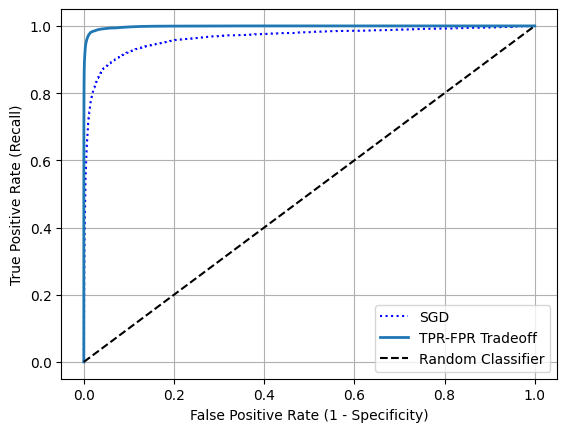

In [ ]:
plt.plot(fpr, tpr, "b:", label = "SGD")
plot_roc_curve(fpr_forest_5, tpr_forest_5, "Random Forest")
plt.legend(loc = "lower right")
plt.show

In [ ]:
roc_auc_score(y_train_5, y_scores_forest_5)

0.9983296721818179

In [ ]:
y_pred_forest_5 = (y_scores_forest_5 >= 0.5)

rf_precision_5 = precision_score(y_train_5, y_pred_forest_5)
rf_recall_5 = recall_score(y_train_5, y_pred_forest_5)

In [ ]:
print(rf_precision_5)
print(rf_recall_5)

0.9895331798199707
0.8719793396052389


As we could see comparing the AUC ROC from SGD and RF, the precision and recall values for RF is actually better and really promising ! 
This was to compare results, but if we would really use this model in the final project, we would need to use cross validation to be more sure about the reliability of the model chose

## Multiclass Classification (Also called Multinomial Classification)

We have different ways to train a multiclass classifier. Some algorithms like Random Forest Classifiers and Naive Bayes Classifiers can handle multiclass directly. 
We indeed have some algorithms as SVM or Linear Classifiers that, a priori, are strictly binary classifiers.
But we have various strategies that we can use to use binary classifiers to perform multiclass classification tasks, as **OvO** and **OvA(OvR)**

Scikit-Learn detects when you try to use a binary classification algorithm for a multi‐class classification task, and it automatically runs OvA (except for SVM classifiers forwhich it uses OvO). Let's try with SGD:

In [ ]:
sgd_clf.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
sgd_clf.predict(some_digit)

array([3], dtype=uint8)

In [ ]:
y_train.iloc[0]   # should return 5

np.uint8(5)

Under the hood, Scikit-Learn actually trained 10 binary classifiers, got their decision scores for the image, and selected the class with the highest score.

### Decision function method to see the scores assigned to each class

In [ ]:
some_digit_score = sgd_clf.decision_function(some_digit)
some_digit_score

array([[-31893.03095419, -19047.55566534,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

The highest score is indeed the one corresponding to class 3.

If we want to force ScikitLearn to use one-versus-one or one-versus-all, you can use the OneVsOneClassifier or OneVsRestClassifier classes. Simply create an instance and pass a binary classifier to its constructor. For example, this code creates a multi‐class classifier using the OvO strategy, based on a SGDClassifier:

In [ ]:
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state = 42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict(some_digit)

array([5], dtype=uint8)

In [ ]:
len(ovo_clf.estimators_)

45

Training a RandomForest Classifier is just as easy (we can use the forest_clf_5 and just change the y_train_5 to y_train):

In [ ]:
forest_clf_5.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
forest_clf_5.predict(some_digit)

array([5], dtype=uint8)

Either using a binary classidier to do multiclass or using a multiclass by itself, OvO or OvA, we want to **evaluate** these classifiers.
Of course we are going to use Cross Validation for this task.

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv = 3, scoring = "accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv = 3, scoring = "accuracy")

/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

### Error Analysis
What kind of errors our model make?

In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv = 3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

A lot of numbers. It's more convinient to look at an image representation of the confusion matrix.

<function matplotlib.pyplot.show(close=None, block=None)>

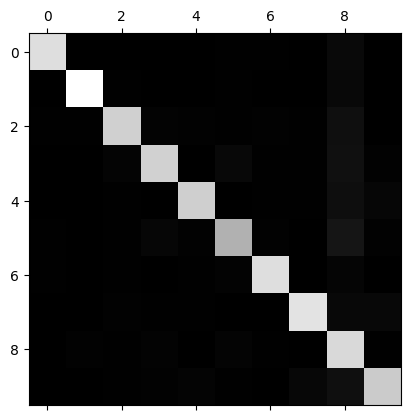

In [ ]:
plt.matshow(conf_mx, cmap = plt.cm.gray)
plt.show

The 5s look slightly darker than the other digits, which could mean that there are fewer images of 5s in the dataset or that the classifier does not perform as well on 5s as on other digits. In fact, we can verify that both are the case.

When we look at a basic confusion matrix, the main diagonal just shows the absolute number of correct predictions (True Positives). Because of this, if we simply have fewer pictures of the number 5 in our dataset, the square for 5 will naturally look darker than the others.
If we aren’t careful, this could trick us into thinking, “Oh, the model must be really bad at recognizing 5s!” — when in reality, it’s just a matter of having less data for that class.
To fix this and get a fair comparison, we divide the absolute numbers by the total number of images in each class. This converts the raw counts into percentages (error rates). By looking at rates instead of totals, we get a much more accurate and honest picture of where the model is actually failing.

In [ ]:
rows_sum = conf_mx.sum(axis = 1, keepdims = True)
norm_conf_mx = conf_mx / rows_sum

Let's fill the main diagonal with 0's to keep only the errors.

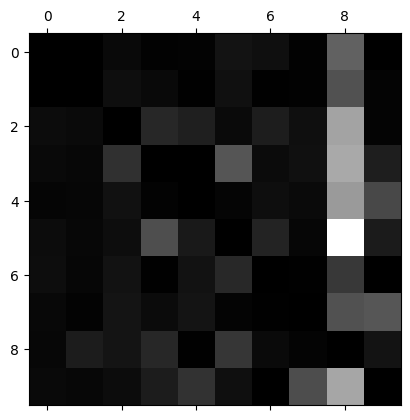

In [ ]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap = plt.cm.gray)
plt.show()

Remember that **rows represent actual classes, while columns represent predicted classes.**

Now we can clearly see the kinds of errors the classifier makes. The column for class 8 is quite bright, which tells you that many images get misclassified as 8s. However, the row for class 8 is not that bad, telling us that actual 8s in general get properly classified as 8s. As we can see, the confusion matrix is not necessarily symmetrical. We can also see that 3s and 5s often get confused (in both directions).

To improve our classifier, one of the best ways would be reducing the false 8's. Some ways:
- gather more training data for digits that look like 8s (but are not) so the classifier can learn to distinguish them from real 8s.
- engineer new features that would help the classifier—for example, writing an algorithm to count the number of closed loops (e.g., 8 has two, 6 has one, 5 has none).
- preprocess the images (e.g., using Scikit-Image, Pillow, or OpenCV) to make some patterns stand out more, such as closed loops.

Analyzing individual errors can also be a good way to gain insights on what your classifier is doing and why it is failing, but it is more difficult and time-consuming. For example, let’s plot examples of 3s and 5s:

In [ ]:
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

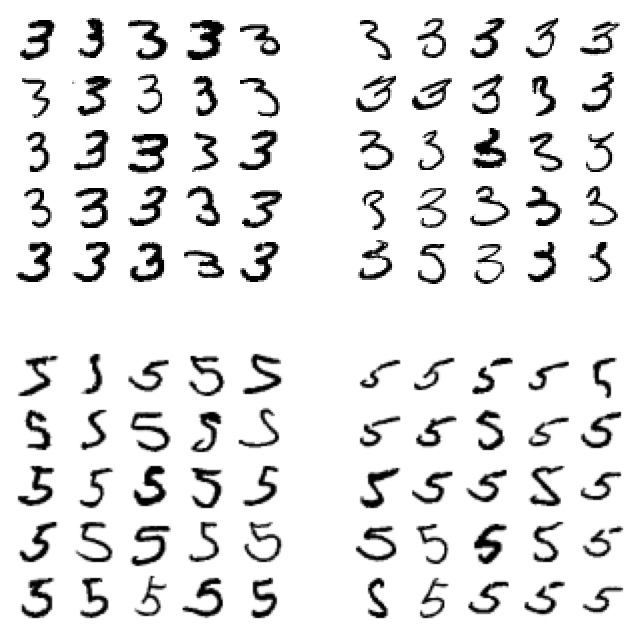

In [ ]:
cl_a, cl_b = 3, 5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

plt.figure(figsize = (8,8))
plt.subplot(221); plot_digits(X_aa[: 25], images_per_row = 5)
plt.subplot(222); plot_digits(X_ab[: 25], images_per_row = 5)
plt.subplot(223); plot_digits(X_ba[: 25], images_per_row = 5)
plt.subplot(224); plot_digits(X_bb[: 25], images_per_row = 5)
plt.show()

Most misclassified images seem like obvious errors to us, and it’s hard to understand why the classifier made the mistakes it did. The reason is that we used a simple SGDClassifier, which is a linear model. All it does is assign a weight per class to each pixel, and when it sees a new image it just sums up the weighted pixel intensities to get a score for each class. So since 3s and 5s differ only by a few pixels, this model will easily confuse them.

The main difference between 3s and 5s is the position of the small line that joins the top line to the bottom arc. If you draw a 3 with the junction slightly shifted to the left, the classifier might classify it as a 5, and vice versa. In other words, this classifier is quite sensitive to image shifting and rotation. So one way to reduce the 3/5 confusion would be to preprocess the images to ensure that they are well centered and not too rotated. This will probably help reduce other errors as well.

### Multi-Label Classification

**Multilabel Classification** is a system where a single input can be assigned **multiple labels at the same time**.

For example, if a face-recognition model looks at a photo containing both Alice and Charlie, it shouldn't just pick one person. Instead, it outputs a set of tags like `[1, 0, 1]` (meaning "Alice yes, Bob no, Charlie yes"). This allows the system to correctly identify all relevant classes for a single image, rather than being restricted to just one.

In [38]:
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
knn_clf.predict(some_digit)

array([[False,  True]])

The digit 5 is indeed not large (False) and odd (True). There are many ways to evaluate a multilabel classifier, and selecting the right metric really depends on your project. For example, one approach is to measure the F1 score for each individual label (or any other binary classifier metric discussed earlier), then simply compute the average score. This code computes the average F1 score across all labels:

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv = 3)
f1_score(y_multilabel, y_train_knn_pred, average = "macro")

0.9764102655606048

In [ ]:
f1_score(y_multilabel, y_train_knn_pred, average = "weighted")

0.9778357403921755

### Multi-Output Classification

We can think of this as a generalization of multilabel classification, where each label can have more than 2 possible values. In multilabel classification, for example, we had labels like Alice, Bob, and Charlie, and if the image was of Bob we would write something like [0,1,0] , meaning each label is just binary. In multi-output classification, though, each output can take more than two values, so it is not limited to True/False anymore. It is like having several classification problems at the same time, one for each output.
We can also use multi-output ideas in regression, not only in classification, so a model can output a mix of classification and regression results too.

In [31]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = mpl.cm.binary,
               interpolation="nearest")
    plt.axis("off")

In [32]:
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

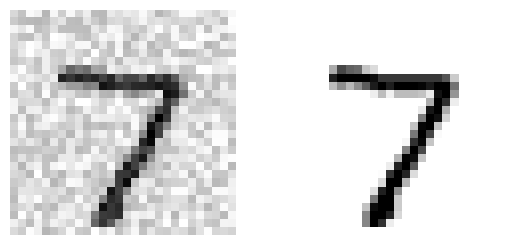

In [36]:
some_index = 0
plt.subplot(121); plot_digit(X_test_mod.iloc[some_index].values)
plt.subplot(122); plot_digit(y_test_mod.iloc[some_index].values)
plt.show()

/Users/viniciusdesouzamori/Documents/mnist_class_exploring/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


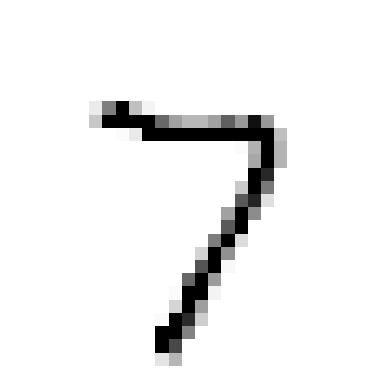

In [40]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod.iloc[some_index].values])
plot_digit(clean_digit)

# Conclusion

Finally, this notebook allowed me to explore the MNIST dataset in practice and deepen my understanding of image classification tasks. Throughout this work, I was able to handle image data represented as pixels, train different classification models, evaluate them using appropriate metrics, and compare their performance in a more structured way. It also helped me develop a clearer understanding of model evaluation metrics, error analysis, confusion matrices, and the importance of choosing suitable methods to interpret a model’s results. More than just applying code, this notebook was valuable for consolidating key concepts of supervised classification and for giving me a better sense of how models can be trained, evaluated, and improved in real-world problems.